# Regression Project

**Database** : [cBioPortal](https://www.cbioportal.org/) <br>

**Choosen dataset** : Breast Carcinoma (MSK, NPJ Precis Oncol 2025) Genomic characterization of 527 tumor mutational burden-high breast carcinomas. [brca_msk_2025](https://www.cbioportal.org/study/clinicalData?id=brca_msk_2025)

**cBioPortal** is an open‑source platform developed for exploring, visualizing, and analyzing **cancer genomics data**. It’s widely used in biomedical research because it integrates **large datasets** from projects like The Cancer Genome Atlas (TCGA) and other studies, making it easier for researchers to study mutations, gene expression, copy number variations, and clinical outcomes.

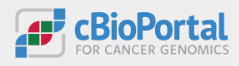

In [1]:
from IPython.display import Image #to display image file
Image('cbio.png')

## 1. Importing dataset

In [2]:
import pandas as pd

# Read TSV file
data = pd.read_csv("brca_msk_2025_clinical_data.tsv", sep="\t")

# Save as CSV file
data.to_csv("brca2025.csv", index=False)

In [3]:
# Read CSV file
df = pd.read_csv("brca2025.csv")

# Display first 3 rows
df.head(3)

,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Fraction Genome Altered,Mutation Count,Oncotree Code,Sample Class,Number of Samples Per Patient,Sample Type,Somatic Status,TMB Score
0,brca_msk_2025,P-0000041,P-0000041-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,0.4041,10,IDC,Tumor,1,Primary,Matched,11.15
1,brca_msk_2025,P-0000138,P-0000138-T01-IM3,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,0.5544,33,MDLC,Tumor,2,Metastasis,Matched,36.80
2,brca_msk_2025,P-0000138,P-0000138-T02-IM3,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,0.0450,14,MDLC,Tumor,2,Metastasis,Matched,15.61


In [4]:
# Display the last 3 rows
df.tail(3)

,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Fraction Genome Altered,Mutation Count,Oncotree Code,Sample Class,Number of Samples Per Patient,Sample Type,Somatic Status,TMB Score
524,brca_msk_2025,P-0081150,P-0081150-T01-IM7,Breast Cancer,Breast Invasive Ductal Carcinoma,0.0574,13,IDC,Tumor,1,Metastasis,Matched,10.71
525,brca_msk_2025,P-0081718,P-0081718-T01-IM7,Breast Cancer,Breast Invasive Ductal Carcinoma,0.2924,20,IDC,Tumor,1,Metastasis,Matched,16.48
526,brca_msk_2025,P-0082317,P-0082317-T01-IM7,Breast Cancer,Breast Invasive Ductal Carcinoma,0.3310,13,IDC,Tumor,1,Metastasis,Matched,12.36


## 2. Exploratory Data Analysis (EDA)

**Why EDA Matters ?** <br>

*a. Ensures data quality before modeling.* <br>

*b. Guides feature selection and preprocessing.* <br>

*c. Helps choose the right ML/DL algorithms.*<br>
 
*d. Prevents misleading conclusions.*<br>

### 2.1. Data Inspection

In [5]:
df.shape  #(n, m) ; n= number of rows/observations/samples \
          #(n, m) ; m=number of columns/features/variables         

(527, 13)

In [6]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Study ID                       527 non-null    object 
 1   Patient ID                     527 non-null    object 
 2   Sample ID                      527 non-null    object 
 3   Cancer Type                    527 non-null    object 
 4   Cancer Type Detailed           527 non-null    object 
 5   Fraction Genome Altered        519 non-null    float64
 6   Mutation Count                 527 non-null    int64  
 7   Oncotree Code                  527 non-null    object 
 8   Sample Class                   527 non-null    object 
 9   Number of Samples Per Patient  527 non-null    int64  
 10  Sample Type                    527 non-null    object 
 11  Somatic Status                 527 non-null    object 
 12  TMB Score                      527 non-null    flo

### 2.2. Missing values & duplicates

#### 2.2.a. Missing values

In [7]:
df.isnull().sum()

Study ID                         0
Patient ID                       0
Sample ID                        0
Cancer Type                      0
Cancer Type Detailed             0
Fraction Genome Altered          8
Mutation Count                   0
Oncotree Code                    0
Sample Class                     0
Number of Samples Per Patient    0
Sample Type                      0
Somatic Status                   0
TMB Score                        0
dtype: int64

Thre is two main strategies for **handling missing data** in datasets: <br>
##### 1.Deletion (Biological/Statistical approach)
**Concept**: Remove rows (or sometimes columns) that contain missing values. <br>
**Advantages**: <br>
Simple and clean. <br>
Avoids introducing artificial values. <br>
**Disadvantages**: <br>
Risk of losing valuable information. <br>
Can bias results if missingness is not random. <br>
**Use case**: <br>
When the dataset is large and the percentage of missing data is very small. <br>
##### 2.Imputation (InformaticStatistical approach)
**Concept**: Fill in missing values with estimated ones. <br>
**Methods**: <br>
***Simple statistics***: mean, median, mode. <br>
***Domain knowledge***: biologically plausible values. <br>
***Advanced ML methods***: k‑NN imputation, regression, deep learning autoencoders. <br>
**Advantages**: <br> 
Preserves dataset size. <br>
Can reduce bias compared to deletion. <br>
**Disadvantages**: <br>
Risk of introducing noise or artificial patterns. <br>
Can bias results if missingness is not random. <br>
**Use case**: <br>
When missing data is more substantial, or when every sample is valuable. <br>

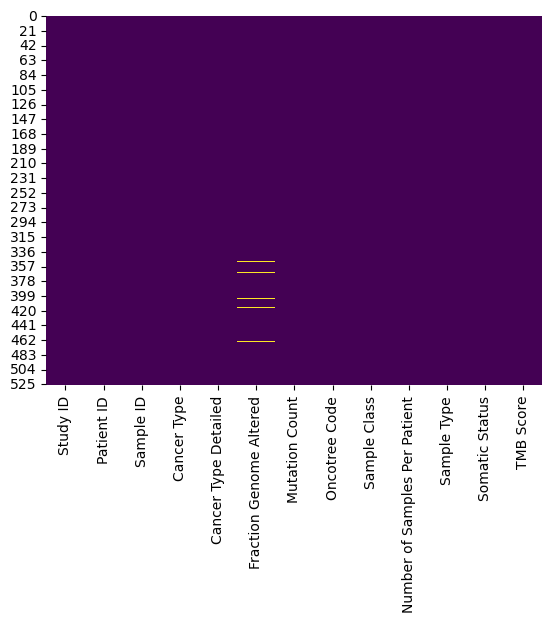

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False, cmap="viridis") #cbar: color bar showing the mapping \
                                                     #between colors and values \
                                                     #cmap: color map - "viridis"; "coolwarm"; etc.
plt.show()

#### 2.2.b. Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

## 2.3. Descriptive Analysis

### 2.3.a. Summary statistics

In [10]:
df.dtypes

Study ID                          object
Patient ID                        object
Sample ID                         object
Cancer Type                       object
Cancer Type Detailed              object
Fraction Genome Altered          float64
Mutation Count                     int64
Oncotree Code                     object
Sample Class                      object
Number of Samples Per Patient      int64
Sample Type                       object
Somatic Status                    object
TMB Score                        float64
dtype: object

In [11]:
df.describe() #for numerical/quantitative variables

,Fraction Genome Altered,Mutation Count,Number of Samples Per Patient,TMB Score
count,519.000000,527.000000,527.000000,527.000000
mean,0.292628,20.354839,1.337761,18.427856
std,0.191989,22.379744,0.796712,19.683099
min,0.000000,6.000000,1.000000,10.040000
25%,0.145050,13.000000,1.000000,11.410000
50%,0.269300,16.000000,1.000000,14.040000
75%,0.413700,22.000000,1.000000,19.770000
max,0.958000,447.000000,6.000000,394.090000


The 527 samples are from the **breast cancer study** brca_msk_2025. The patient identifier reveals that some patients appear multiple times (e.g., patient "P-0023357" six times), while the sample identifier appears only once. <br>
Therefore, during preprocessing, all features associated with this identifier (Study ID, Patient ID, Cancer Type,  Sample Class) must be removed.

In [12]:
for col in df.select_dtypes(include='object').columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n" + "-"*40 + "\n")

Value counts for Study ID:
Study ID
brca_msk_2025    527
Name: count, dtype: int64

----------------------------------------

Value counts for Patient ID:
Patient ID
P-0023357    6
P-0008398    4
P-0029064    4
P-0058643    3
P-0002911    3
            ..
P-0017930    1
P-0017478    1
P-0017368    1
P-0017015    1
P-0082317    1
Name: count, Length: 462, dtype: int64

----------------------------------------

Value counts for Sample ID:
Sample ID
P-0000041-T01-IM3    1
P-0040964-T01-IM6    1
P-0040328-T01-IM6    1
P-0040166-T01-IM6    1
P-0040098-T03-IM7    1
                    ..
P-0014907-T01-IM6    1
P-0014828-T01-IM6    1
P-0014755-T01-IM6    1
P-0014702-T01-IM6    1
P-0082317-T01-IM7    1
Name: count, Length: 527, dtype: int64

----------------------------------------

Value counts for Cancer Type:
Cancer Type
Breast Cancer    527
Name: count, dtype: int64

----------------------------------------

Value counts for Cancer Type Detailed:
Cancer Type Detailed
Breast Invasive Ductal

In [13]:
df.describe(include='object')  #for categorical attributes

,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Oncotree Code,Sample Class,Sample Type,Somatic Status
count,527,527,527,527,527,527,527,527,527
unique,1,462,527,1,8,8,1,4,2
top,brca_msk_2025,P-0023357,P-0000041-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Tumor,Metastasis,Matched
freq,527,6,1,527,205,205,527,401,517


In [14]:
df.iloc[: ,0].unique()

array(['brca_msk_2025'], dtype=object)

In [15]:
df.iloc[: ,3].unique()

array(['Breast Cancer'], dtype=object)

In [16]:
df.iloc[: ,4].unique()

array(['Breast Invasive Ductal Carcinoma',
       'Breast Mixed Ductal and Lobular Carcinoma',
       'Breast Invasive Lobular Carcinoma', 'Invasive Breast Carcinoma',
       'Breast Invasive Cancer, NOS', 'Breast Invasive Carcinoma, NOS',
       'Breast Neoplasm, NOS', 'Breast Invasive Carcinosarcoma, NOS'],
      dtype=object)

In [17]:
df["Oncotree Code"].unique()

array(['IDC', 'MDLC', 'ILC', 'BRCA', 'BRCANOS', 'BRCNOS', 'BNNOS',
       'CSNOS'], dtype=object)

### 2.3.b. Data Visualization

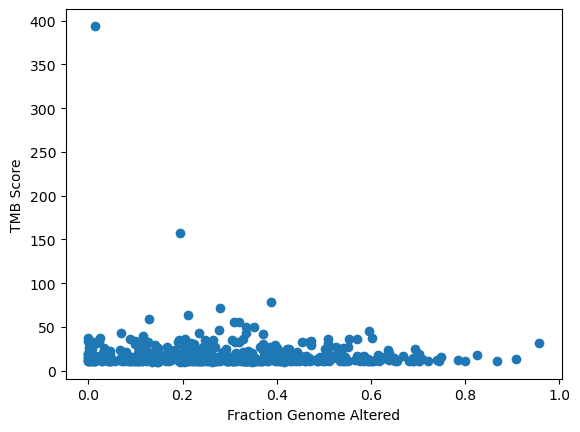

In [18]:
#visualize the relationship between two numerical/quantitif attributes
plt.scatter(x = df["Fraction Genome Altered"], y = df["TMB Score"])

df_filtered = df[df["TMB Score"] > 100]

plt.xlabel('Fraction Genome Altered')
plt.ylabel('TMB Score')
plt.show()


#no probable linear relationship between both variables, but we observe
#that there is some extreme value

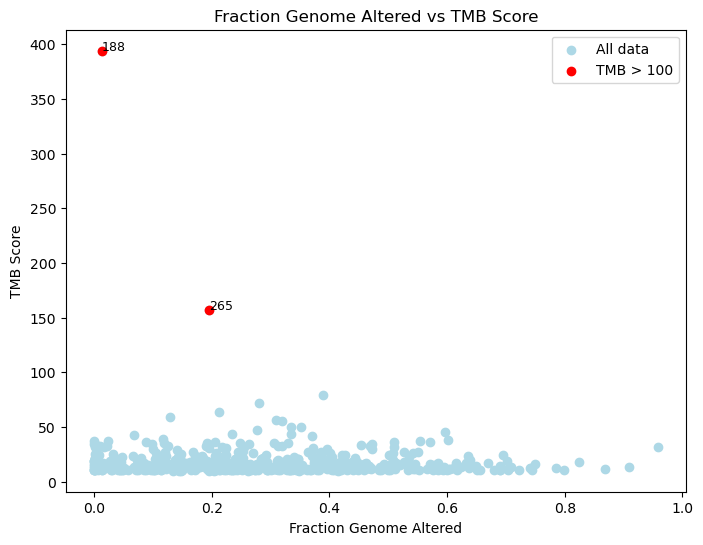

In [19]:
plt.figure(figsize=(8,6))

# Plot all points
plt.scatter(df["Fraction Genome Altered"], df["TMB Score"], 
            color="lightblue", label="All data")

# Filtered points
df_filtered = df[df["TMB Score"] > 100]
plt.scatter(df_filtered["Fraction Genome Altered"], df_filtered["TMB Score"], 
            color="red", label="TMB > 100")

# Add labels for filtered points
for i in df_filtered.index:
    plt.text(df_filtered.loc[i, "Fraction Genome Altered"], 
             df_filtered.loc[i, "TMB Score"], 
             str(i), fontsize=9, color="black")

plt.xlabel("Fraction Genome Altered")
plt.ylabel("TMB Score")
plt.title("Fraction Genome Altered vs TMB Score")
plt.legend()
plt.show()

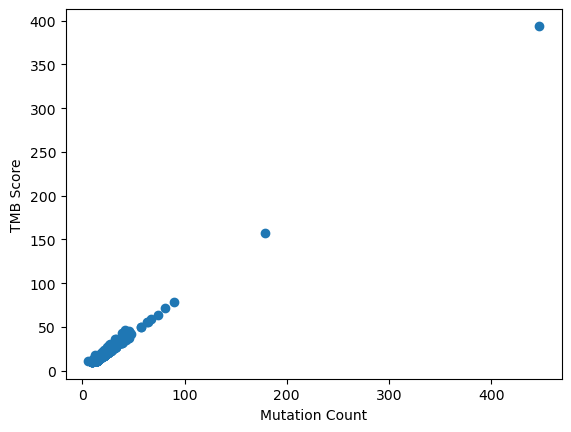

In [20]:
plt.scatter(x = df["Mutation Count"], y = df["TMB Score"])
plt.xlabel('Mutation Count')
plt.ylabel('TMB Score')
plt.show()

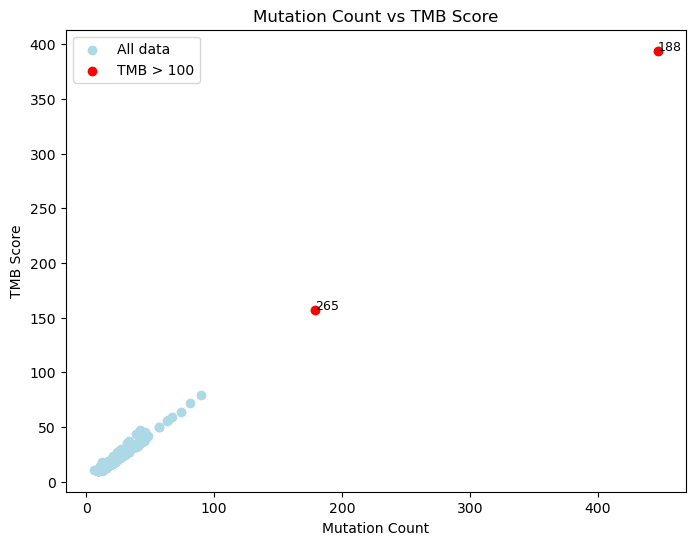

In [21]:
plt.figure(figsize=(8,6))

# Plot all points
plt.scatter(df["Mutation Count"], df["TMB Score"], 
            color="lightblue", label="All data")

# Filtered points
df_filtered = df[df["TMB Score"] > 100]
plt.scatter(df_filtered["Mutation Count"], df_filtered["TMB Score"], 
            color="red", label="TMB > 100")

# Add labels for filtered points
for i in df_filtered.index:
    plt.text(df_filtered.loc[i, "Mutation Count"], 
             df_filtered.loc[i, "TMB Score"], 
             str(i), fontsize=9, color="black")

plt.xlabel("Mutation Count")
plt.ylabel("TMB Score")
plt.title("Mutation Count vs TMB Score")
plt.legend()
plt.show()

### 2.3.c. Statistical Analysis

Study **Quantitative–Quantitative Relationships** through correlation coefficient

In [22]:
df_numeric = df.select_dtypes(include=["float64", "int64"])

In [23]:
correlations = df_numeric.corr(method="pearson") #pearson because we have more than 500 observations

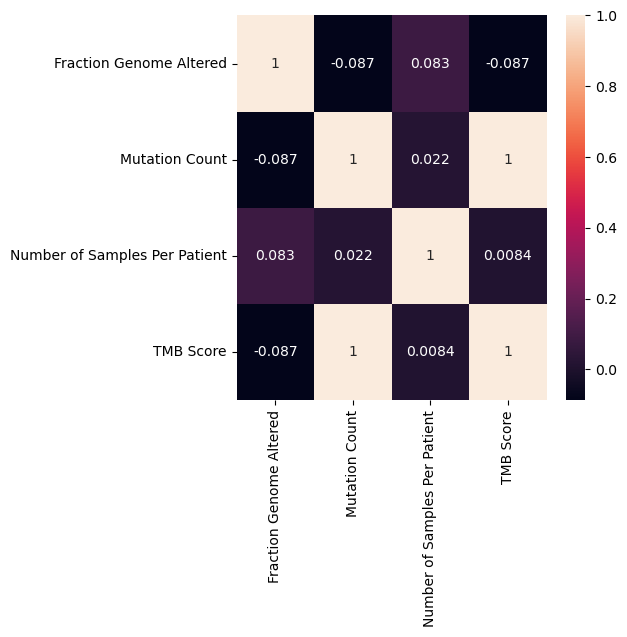

In [24]:
plt.subplots(figsize=(5,5))
sns.heatmap(correlations, annot = True)
plt.show()   #not all the cells were annotated because of NaN values in the correlation matrix

Based on the observed distributions, none of the quantitative variables visually follow a centered normal distribution, and they also have different measurement scales. <br>
→ Normalization / Standardization is required.

<Axes: ylabel='Density'>

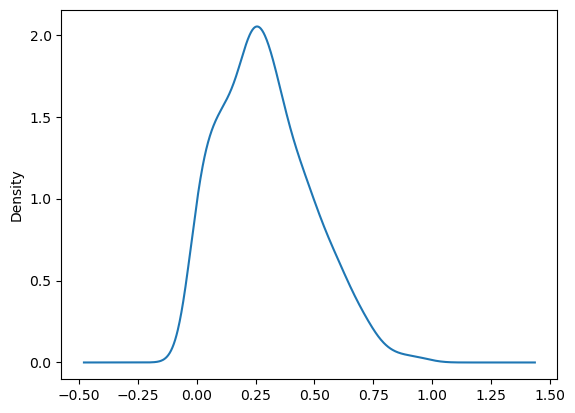

In [25]:
df['Fraction Genome Altered'].plot.density()

<Axes: ylabel='Density'>

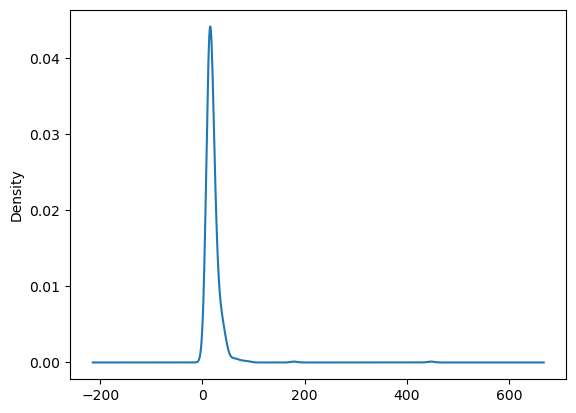

In [26]:
df['Mutation Count'].plot.density()

<Axes: ylabel='Density'>

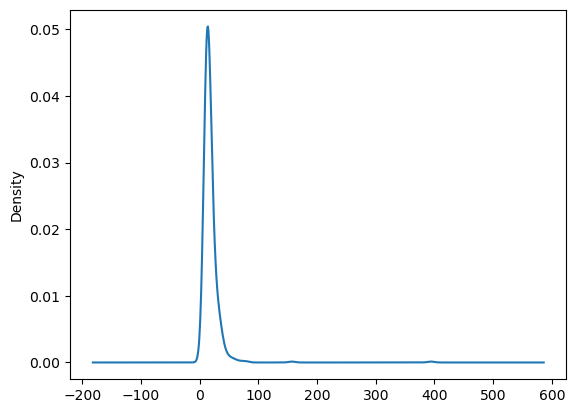

In [27]:
df['TMB Score'].plot.density()

## 3. Data Pre-Processing

### 3.1. Data Cleaning and Feature Selection/Engineering

Drop irrelevant columns (IDs, free text not useful for modeling).

Create new features (e.g., BMI from weight/height).

Encode domain‑specific variables.

In [28]:
# Drop columns with missing values
#####df_clean = df.dropna(axis=1)
# Drop rows with missing values in a specific column
df_clean = df.dropna(subset = [df.columns[5]])

In [29]:
df_clean.isnull().sum()

Study ID                         0
Patient ID                       0
Sample ID                        0
Cancer Type                      0
Cancer Type Detailed             0
Fraction Genome Altered          0
Mutation Count                   0
Oncotree Code                    0
Sample Class                     0
Number of Samples Per Patient    0
Sample Type                      0
Somatic Status                   0
TMB Score                        0
dtype: int64

In [30]:
print ("The dimension of our dataset was ", df.shape, " and became ", df_clean.shape)

The dimension of our dataset was  (527, 13)  and became  (519, 13)


In [31]:
# Indices to drop
drop_idx = [0, 1, 2, 3, 8, 10]

# Drop those columns
df_clean = df_clean.drop(df_clean.columns[drop_idx], axis=1) #df_final contain final set

In [32]:
df_clean.dtypes

Cancer Type Detailed              object
Fraction Genome Altered          float64
Mutation Count                     int64
Oncotree Code                     object
Number of Samples Per Patient      int64
Somatic Status                    object
TMB Score                        float64
dtype: object

In [33]:
df_clean.isnull().sum()

Cancer Type Detailed             0
Fraction Genome Altered          0
Mutation Count                   0
Oncotree Code                    0
Number of Samples Per Patient    0
Somatic Status                   0
TMB Score                        0
dtype: int64

### 3.2. Feature Encoding

#### 3.2.a. Transform Object to Category

In [34]:
# Convert all object columns to categorical
df_corr = df_clean
for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = df_corr[col].astype("category") #df_corr contain cetegorical attributes

In [35]:
df_corr.dtypes

Cancer Type Detailed             category
Fraction Genome Altered           float64
Mutation Count                      int64
Oncotree Code                    category
Number of Samples Per Patient       int64
Somatic Status                   category
TMB Score                         float64
dtype: object

In [36]:
df_corr.isnull().sum()

Cancer Type Detailed             0
Fraction Genome Altered          0
Mutation Count                   0
Oncotree Code                    0
Number of Samples Per Patient    0
Somatic Status                   0
TMB Score                        0
dtype: int64

The "Cancer Type Detailed" attribute has 8 subgroups, two of which (Breast Neoplasia, NOS; Invasive Breast Carcinosarcoma, NOS) contain **only one sample each**. <br>
Carcinosarcoma is a rare subtype; however, the "Carcinoma NOS," "Cancer NOS," and "Neoplasia NOS" subgroups are similar enough to be grouped under the name "Invasive Carcinoma Not Specified." <br>
Similarly, the "Oncotree Code" subgroup has 8 subgroups, two of which (BNNOS; CSNOS) contain **only one sample each**. <br>
Therefore, we will first remove the **BNNOS and CSNOS subgroups**, and then merge the remaining subgroups if they are still present.

In [37]:
###df_corr = df_corr[df_corr.iloc[; , 8] != "BNNOS"]
#Instead we use ; isin([...]) - pandas method & ~ to invert the output value from isin
#the subgroups with only one observation were thus removed in both variables
df_corr = df_corr[~df_corr.iloc[: , 3].isin(["BNNOS", "CSNOS"])]

In [38]:
for col in df_corr.select_dtypes(include='category').columns: 
    print(f"Value counts for {col}:")
    print(df_corr[col].value_counts())
    print("\n" + "-"*40 + "\n")

Value counts for Cancer Type Detailed:
Cancer Type Detailed
Breast Invasive Ductal Carcinoma             203
Invasive Breast Carcinoma                    142
Breast Invasive Lobular Carcinoma            102
Breast Invasive Carcinoma, NOS                40
Breast Invasive Cancer, NOS                   18
Breast Mixed Ductal and Lobular Carcinoma     12
Breast Invasive Carcinosarcoma, NOS            0
Breast Neoplasm, NOS                           0
Name: count, dtype: int64

----------------------------------------

Value counts for Oncotree Code:
Oncotree Code
IDC        203
BRCA       142
ILC        102
BRCNOS      40
BRCANOS     18
MDLC        12
BNNOS        0
CSNOS        0
Name: count, dtype: int64

----------------------------------------

Value counts for Somatic Status:
Somatic Status
Matched      508
Unmatched      9
Name: count, dtype: int64

----------------------------------------



In [39]:
df_corr.isnull().sum()

Cancer Type Detailed             0
Fraction Genome Altered          0
Mutation Count                   0
Oncotree Code                    0
Number of Samples Per Patient    0
Somatic Status                   0
TMB Score                        0
dtype: int64

#### 3.2.b. One Hot Encoding

In [40]:
df_corr.dtypes

Cancer Type Detailed             category
Fraction Genome Altered           float64
Mutation Count                      int64
Oncotree Code                    category
Number of Samples Per Patient       int64
Somatic Status                   category
TMB Score                         float64
dtype: object

In [41]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = df_corr.select_dtypes(include=['category']).columns

# --- OneHotEncoder for categorical columns ---
encoder = OneHotEncoder(sparse_output=False, drop=None)
encoded_array = encoder.fit_transform(df_corr[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

df_encoded = pd.DataFrame(encoded_array, 
                          columns=encoded_cols, 
                          index=df_corr.index)   # keep same index

#### 3.2.c. Label Encoder

In [42]:
from sklearn.preprocessing import LabelEncoder
# --- LabelEncoder for binary column ---
label_encoder = LabelEncoder()
encoded = label_encoder.fit_transform(df_corr["Somatic Status"])

df_somatic = pd.DataFrame(encoded, 
                          columns=["Somatic Status"], 
                          index=df_corr.index)   # keep same index

#### 3.2.d. Numerical transformation

Scale features (e.g., StandardScaler, MinMaxScaler).

Normalize distributions if needed (log transform for skewed data).

In [43]:
from sklearn.preprocessing import StandardScaler
# --- StandardScaler for numerical columns ---
numerical_cols = df_corr.select_dtypes(include=["int64", "float64"]).columns
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_corr[numerical_cols])

df_scaled = pd.DataFrame(scaled_array, 
                         columns=numerical_cols, 
                         index=df_corr.index)   # keep same index

### 3.2.e. Built the new set

In [44]:
# --- Combine everything back together ---
df_final = pd.concat([df_encoded, df_somatic, df_scaled], axis=1)

print(df_corr.shape)   # original rows
print(df_final.shape)  # should match row count


(517, 7)
(517, 19)


In [45]:
df_final.isnull().sum()

Cancer Type Detailed_Breast Invasive Cancer, NOS                  0
Cancer Type Detailed_Breast Invasive Carcinoma, NOS               0
Cancer Type Detailed_Breast Invasive Ductal Carcinoma             0
Cancer Type Detailed_Breast Invasive Lobular Carcinoma            0
Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma    0
Cancer Type Detailed_Invasive Breast Carcinoma                    0
Oncotree Code_BRCA                                                0
Oncotree Code_BRCANOS                                             0
Oncotree Code_BRCNOS                                              0
Oncotree Code_IDC                                                 0
Oncotree Code_ILC                                                 0
Oncotree Code_MDLC                                                0
Somatic Status_Matched                                            0
Somatic Status_Unmatched                                          0
Somatic Status                                  

In [46]:
df_final.dtypes

Cancer Type Detailed_Breast Invasive Cancer, NOS                  float64
Cancer Type Detailed_Breast Invasive Carcinoma, NOS               float64
Cancer Type Detailed_Breast Invasive Ductal Carcinoma             float64
Cancer Type Detailed_Breast Invasive Lobular Carcinoma            float64
Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma    float64
Cancer Type Detailed_Invasive Breast Carcinoma                    float64
Oncotree Code_BRCA                                                float64
Oncotree Code_BRCANOS                                             float64
Oncotree Code_BRCNOS                                              float64
Oncotree Code_IDC                                                 float64
Oncotree Code_ILC                                                 float64
Oncotree Code_MDLC                                                float64
Somatic Status_Matched                                            float64
Somatic Status_Unmatched              

#### 3.3. Train/Test Split

Separate dataset into training and testing sets (e.g., 80/20 split).

In [47]:
df_mod = df_final
df_mod.columns

Index(['Cancer Type Detailed_Breast Invasive Cancer, NOS',
       'Cancer Type Detailed_Breast Invasive Carcinoma, NOS',
       'Cancer Type Detailed_Breast Invasive Ductal Carcinoma',
       'Cancer Type Detailed_Breast Invasive Lobular Carcinoma',
       'Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma',
       'Cancer Type Detailed_Invasive Breast Carcinoma', 'Oncotree Code_BRCA',
       'Oncotree Code_BRCANOS', 'Oncotree Code_BRCNOS', 'Oncotree Code_IDC',
       'Oncotree Code_ILC', 'Oncotree Code_MDLC', 'Somatic Status_Matched',
       'Somatic Status_Unmatched', 'Somatic Status', 'Fraction Genome Altered',
       'Mutation Count', 'Number of Samples Per Patient', 'TMB Score'],
      dtype='object')

In [48]:
X = df_mod.iloc[:,0:16].values 
y = df_mod.iloc[:,16].values

In [49]:
y

array([-4.59295001e-01,  5.60207866e-01, -2.81990155e-01,  2.49924385e-01,
       -4.14968790e-01, -5.03621213e-01, -1.60328851e-02, -4.59295001e-01,
       -4.14968790e-01, -2.81990155e-01, -4.59295001e-01, -4.14968790e-01,
       -4.14968790e-01, -1.49011520e-01, -4.14968790e-01, -1.49011520e-01,
       -5.03621213e-01, -5.03621213e-01, -1.93337732e-01, -3.70642578e-01,
       -6.03590967e-02, -5.03621213e-01, -1.60328851e-02, -4.14968790e-01,
       -2.37663943e-01,  1.61271961e-01, -5.03621213e-01, -4.59295001e-01,
        2.94250596e-01,  8.26165136e-01, -4.14968790e-01, -4.59295001e-01,
       -4.59295001e-01, -3.70642578e-01,  2.82933266e-02,  9.59143770e-01,
        7.37512712e-01,  2.94250596e-01, -5.03621213e-01, -5.03621213e-01,
       -3.26316366e-01, -3.70642578e-01,  5.15881654e-01, -3.26316366e-01,
        8.70491347e-01,  1.00346998e+00, -5.03621213e-01, -2.37663943e-01,
       -1.49011520e-01, -1.60328851e-02,  4.27229231e-01, -2.37663943e-01,
       -2.37663943e-01,  

In [50]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#To ensure reproducibility and repeatability, a random state correction

## 4. Data Modeling

In [51]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors = 5)
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)

## 5. Model Evaluation Metrics

We compute several metrics to evaluate the quality of our KNN regression model:


**Coefficient of Determination (R²)**


$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

**Explanation:** Measures how much of the variance in the dependent variable \(y\) is explained by the model. Values range from 0 to 1 (higher is better).


**Adjusted R²**


$$
R^2_{\text{adj}} = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}
$$



where \(n\) = number of samples, \(p\) = number of predictors.

**Explanation:** Adjusts R² for the number of predictors \(p\). Prevents overestimation when adding more variables that don’t improve the model.

**Correlation-based R²**


$$
R^2_{\text{corr}} = \big(\text{corr}(y, \hat{y})\big)^2
$$

**Explanation:** Square of the correlation coefficient between actual and predicted values. Useful when comparing predictive accuracy directly via correlation.


**Mean Squared Error (MSE)**


$$
MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

**Explanation:** Average of squared differences between actual and predicted values. Penalizes larger errors more strongly.


**Mean Absolute Error (MAE)**
$$
MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|
$$
**Explanation:** Average of absolute differences between actual and predicted values. Unlike MSE, it does not penalize large errors as heavily, making it more robust to outliers.


**Root Mean Squared Error (RMSE)**


$$
RMSE = \sqrt{MSE}
$$

**Explanation:** Square root of MSE. Expressed in the same units as the target variable, making it more interpretable.



**Comparison Table**

| Metric          | Formula                                                                 | Range        | Interpretation                                                                 |
|-----------------|-------------------------------------------------------------------------|--------------|--------------------------------------------------------------------------------|
| **R²**          | $$1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$        | 0 to 1       | Proportion of variance explained by the model                                  |
| **Adjusted R²** | $$1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$                              | ≤ R²         | Corrects R² for number of predictors, avoids inflation                         |
| **Corr R²**     | $$(\text{corr}(y, \hat{y}))^2$$                                        | 0 to 1       | Strength of linear relationship between actual and predicted values            |
| **MSE**         | $$\frac{1}{n} \sum (y_i - \hat{y}_i)^2$$                               | ≥ 0          | Average squared error, sensitive to large deviations                           |
| **MAE**         | $$\frac{1}{n} \sum |y_i - \hat{y}_i|$$                                 | ≥ 0          | Average absolute error, less sensitive to outliers than MSE                    |
| **RMSE**        | $$\sqrt{MSE}$$                                                         | ≥ 0          | Error in same units as target variable, easier to interpret than MSE           |

In [52]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- R² from sklearn ---
R2 = r2_score(y_test, y_pred_knn)

# --- Adjusted R² ---
n = X_test.shape[0]   # number of samples
p = X_test.shape[1]   # number of features
adj_R2 = 1 - (1 - R2) * (n - 1) / (n - p - 1)

# --- R² via correlation squared (like in R script) ---
Rsquare = np.corrcoef(y_pred_knn, y_test)[0,1]**2

# --- MSE, MAE & RMSE ---
MSE = mean_squared_error(y_test, y_pred_knn)
MAE = mean_absolute_error(y_test, y_pred_knn)
RMSE = np.sqrt(MSE)

# --- Comparison table ---
comp = pd.DataFrame({
    "R2": [R2],
    "Adjusted R2": [adj_R2],
    "Rsquare (corr^2)": [Rsquare],
    "MSE": [MSE], "MAE": [MAE],
    "RMSE": [RMSE]
}, index = ["KNN-5"])

print(comp)

             R2  Adjusted R2  Rsquare (corr^2)       MSE      MAE      RMSE
KNN-5 -0.650039    -0.953494           0.00164  0.485013  0.37916  0.696428


**Interpretation of KNN‑5 Regression Metrics**

**Metric Interpretations**

- **R² = 0.669**  
  The model explains about **67% of the variance** in the target variable. This indicates a reasonably strong fit, though not perfect.

- **Adjusted R² = 0.609**  
  After adjusting for the number of predictors, the explanatory power drops slightly. This shows that while the model captures variance, some predictors may not add much value.

- **Correlation-based R² = 0.774**  
  The squared correlation between actual and predicted values is higher than the variance-based R². This suggests predictions track actual values quite closely in terms of linear association.

- **MSE = 0.094**  
  The average squared error is **0.094**. Because errors are squared, large deviations weigh more heavily.

- **MAE = 0.158**  
  The average absolute error is **0.158 units**. This is more intuitive than MSE, since it represents the typical error magnitude without over‑penalizing outliers.

- **RMSE = 0.307**  
  The typical prediction error is about **0.31 units** in the same scale as the target variable. This is easier to interpret than MSE and shows the expected deviation size.

---

**Comparison Table**

| Metric              | Value     | Interpretation                                                                 |
|---------------------|-----------|--------------------------------------------------------------------------------|
| **R²**              | 0.669     | 67% of variance explained by the model                                          |
| **Adjusted R²**     | 0.609     | Corrected for predictors; slightly lower, showing modest overfitting risk       |
| **Corr R²**         | 0.774     | Strong correlation between actual and predicted values                          |
| **MSE**             | 0.094     | Average squared error; sensitive to large deviations                            |
| **MAE**             | 0.158     | Average absolute error; more robust to outliers than MSE                        |
| **RMSE**            | 0.307     | Typical prediction error in target’s units, easier to interpret than MSE        |

---

**Key Takeaways**
- The KNN‑5 model has **moderate to strong explanatory power**.  
- **Adjusted R² being lower** suggests some predictors may not contribute much.  
- **Correlation R² is higher**, showing predictions align well with actual values.  
- **MAE (0.158)** indicates the average prediction error is small and interpretable.  
- **RMSE (0.31)** gives a practical sense of the error magnitude in the same units as the target.  

👉 In short: the model performs decently, with predictions closely aligned to actual outcomes, and errors are relatively small.